Download successful.
Detected 1 distinct shapes.

ID    | Match Score  | Similarity Result
----------------------------------------
0     | 0.00000      | REFERENCE


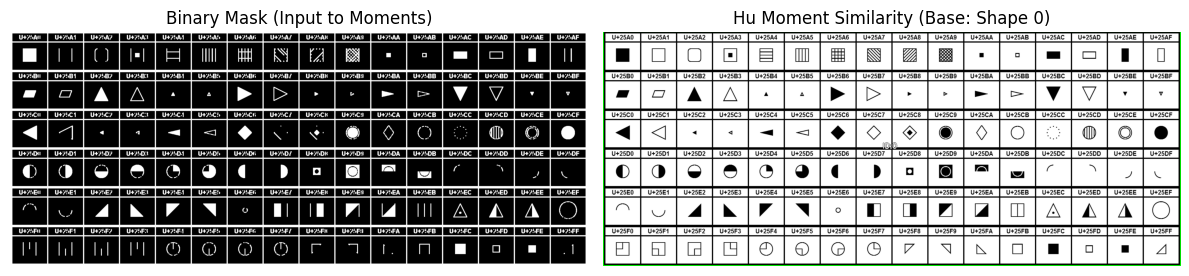

In [3]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import requests
import os

# 1. Download the specific UCB Geometric Shapes image
def get_image():
    filename = 'ucb_shapes.png'
    url = "https://upload.wikimedia.org/wikipedia/commons/4/4c/UCB_Geometric_Shapes.png"
    
    if not os.path.exists(filename):
        print("Downloading image...")
        try:
            # Added headers to mimic a browser to avoid 403 Forbidden errors
            headers = {'User-Agent': 'Mozilla/5.0'}
            r = requests.get(url, headers=headers, timeout=10)
            r.raise_for_status()
            with open(filename, 'wb') as f:
                f.write(r.content)
            print("Download successful.")
        except Exception as e:
            print(f"Download failed: {e}. Creating fallback shapes.")
            # Fallback: Create synthetic shapes if the link is down
            img = np.ones((500, 800, 3), dtype=np.uint8) * 255
            cv2.circle(img, (200, 250), 80, (255, 0, 0), -1) # Reference Circle
            cv2.rectangle(img, (400, 170), (560, 330), (0, 255, 0), -1) # Square
            cv2.circle(img, (700, 250), 60, (255, 0, 0), -1) # Similar Circle
            cv2.imwrite(filename, img)
    return filename

# 2. Preprocess to isolate shapes
def preprocess(filename):
    img = cv2.imread(filename)
    if img is None:
        return None, None
    
    # Convert to grayscale
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    
    # Use Otsu's thresholding to handle the white/colorful background
    # We invert it because findContours looks for white objects on black backgrounds
    _, binary = cv2.threshold(gray, 230, 255, cv2.THRESH_BINARY_INV)
    
    # Clean up small noise with a morphological opening
    kernel = np.ones((3,3), np.uint8)
    binary = cv2.morphologyEx(binary, cv2.MORPH_OPEN, kernel)
    
    return img, binary

# 3. Extract and Sort Contours
def get_sorted_contours(binary):
    contours, _ = cv2.findContours(binary, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    
    # Filter by area to ignore noise, then sort left-to-right, top-to-bottom
    valid_contours = [c for c in contours if cv2.contourArea(c) > 1000]
    
    def get_contour_precedence(contour, cols):
        tolerance_factor = 10
        origin = cv2.boundingRect(contour)
        return ((origin[1] // tolerance_factor) * tolerance_factor) * cols + origin[0]

    valid_contours.sort(key=lambda x: get_contour_precedence(x, binary.shape[1]))
    return valid_contours

# 4. Main Logic
def main():
    path = get_image()
    img, binary = preprocess(path)
    
    if img is None:
        print("Error: Could not load image file.")
        return

    contours = get_sorted_contours(binary)
    print(f"Detected {len(contours)} distinct shapes.")

    # We compare everything against the first shape detected (Shape 0)
    ref_contour = contours[0]
    out_img = img.copy()

    print(f"\n{'ID':<5} | {'Match Score':<12} | {'Similarity Result'}")
    print("-" * 40)

    for i, cnt in enumerate(contours):
        # Calculate Match Score using Hu Moments (Method I1)
        # Score of 0.0 is a perfect structural match
        score = cv2.matchShapes(ref_contour, cnt, cv2.CONTOURS_MATCH_I1, 0.0)

        # Categorize similarity
        if i == 0: 
            label = "REFERENCE"
        elif score < 0.02: 
            label = "Identical Structure"
        elif score < 0.1: 
            label = "Very Similar"
        elif score < 0.3: 
            label = "Similar"
        else: 
            label = "Different"

        print(f"{i:<5} | {score:<12.5f} | {label}")

        # Visualization: Draw contour and ID
        M = cv2.moments(cnt)
        if M["m00"] != 0:
            cx = int(M["m10"] / M["m00"])
            cy = int(M["m01"] / M["m00"])
            
            # Draw contour in green
            cv2.drawContours(out_img, [cnt], -1, (0, 255, 0), 3)
            # Add text label
            cv2.putText(out_img, f"ID:{i}", (cx - 30, cy), 
                        cv2.FONT_HERSHEY_SIMPLEX, 0.8, (0, 0, 0), 4) # Outline
            cv2.putText(out_img, f"ID:{i}", (cx - 30, cy), 
                        cv2.FONT_HERSHEY_SIMPLEX, 0.8, (255, 255, 255), 2)

    # 5. Show Results
    plt.figure(figsize=(12, 8))
    plt.subplot(1, 2, 1)
    plt.title("Binary Mask (Input to Moments)")
    plt.imshow(binary, cmap='gray')
    plt.axis('off')

    plt.subplot(1, 2, 2)
    plt.title("Hu Moment Similarity (Base: Shape 0)")
    plt.imshow(cv2.cvtColor(out_img, cv2.COLOR_BGR2RGB))
    plt.axis('off')

    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    main()